In [1]:
# ============================================================================
# RF2-E — abstention / ambiguity taxonomy   (D plane, NON_CANONICAL)
# 이 노트북은 결과를 만들지 않는다. tools/rf2_e_abstention_taxonomy.py 가 만든
# results/RF2_E_abstention_taxonomy.json 을 읽어 표와 그림으로 렌더할 뿐이다.
# ============================================================================
META = {
    "research_question": "현재 ambiguous/abstain 케이스를 원인별로 taxonomy 하고, 각 유형이 더 나은 evidence 로 해결 가능한지 원리적으로 미결정인지 가른다. 그리고 '어디에서 abstain 해야 하는가' 에 답한다.",
    "child_id": "D-RF2-E",
    "parent_rq_id": "RQ-D-RF-002",
    "hypothesis_id": "H-RF2-E-ABSTENTION-TAXONOMY",
    "competing_hypotheses": [
        "H-E1 대부분이 evidence 부족(수집으로 해결)",
        "H-E2 대부분이 원리적 미결정(수집해도 안 됨)",
        "H-E3 유형이 뒤섞여 분류 자체가 불안정"
    ],
    "input_snapshot_sha": {
        "D_OBSERVATION_TABLE_v2.csv": "c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b",
        "D_TEXT_CORPUS_v2.csv": "bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a",
        "RF001_A_rule_dt.json": "c27078736813e74fa9ccf69d1aa92505e6e38147a10e14022d32c5f7b3c9a650",
        "RF001_C_embedding.json": "f0efd39ffe9ef5fe4b835594daf0eaf9333d2a29bc63efd5b39be006490c6651",
        "INPUT_SNAPSHOT_v21.json": "f92ef2aa14efc9c957ec827d3a5936f3f79443616e5d5622ffef9f5f9dd8f188"
    },
    "code_sha": {
        "tools/rf2_e_abstention_taxonomy.py": "208dafb8810041227cdb4b88fe7f3d06f69e02afd102c588f645769260c17843"
    },
    "result_sha": {
        "results/RF2_E_abstention_taxonomy.json": "eaab14e60ea5b7e34fe77ac161672eb79e86b89c945c8a3a0e7139a35d0baec4"
    },
    "mlflow_run_id": "17e95f2163374200a3cbfa190b077933",
    "mlflow_experiment": "LA_03_RF_MAPPING",
    "mlflow_parent_run_id": "ae754858ba3a4be391e5f811640d3fd8",
    "n": {
        "targets_in_mart": 56,
        "abstain": 40,
        "unresolved_incl_stage0": 45,
        "rule_mapped": 11
    },
    "grain": "target (wtg, in_mart==1)",
    "seed": 20260827,
    "model_or_rule_version": "RF2E_TAXONOMY_v1",
    "target_variable_warning": "prior_archetype 은 gold label 이 아니라 prior 다. 지표 이름은 prior_agreement 이며 accuracy 가 아니다.",
    "firewall": "holdout label 을 열지 않았다 — LABEL_SPLIT_FROZEN*, HOLDOUT_FOR_C*, RAW_L1~L4*, PACKET_L*, *_OVERLAP*, PRECEDENCE_CONTESTED*, CALIBRATION_FOR_B*, **/control/** 은 이 분석에서 한 번도 읽지 않았다. 그래서 threshold 를 선언하지 않는다.",
    "verdict": "PARTIALLY_SUPPORTED"
}

import json
for k, v in META.items():
    print(f"{k:<26} {v if not isinstance(v, (dict, list)) else json.dumps(v, ensure_ascii=False)}")

research_question          현재 ambiguous/abstain 케이스를 원인별로 taxonomy 하고, 각 유형이 더 나은 evidence 로 해결 가능한지 원리적으로 미결정인지 가른다. 그리고 '어디에서 abstain 해야 하는가' 에 답한다.
child_id                   D-RF2-E
parent_rq_id               RQ-D-RF-002
hypothesis_id              H-RF2-E-ABSTENTION-TAXONOMY
competing_hypotheses       ["H-E1 대부분이 evidence 부족(수집으로 해결)", "H-E2 대부분이 원리적 미결정(수집해도 안 됨)", "H-E3 유형이 뒤섞여 분류 자체가 불안정"]
input_snapshot_sha         {"D_OBSERVATION_TABLE_v2.csv": "c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b", "D_TEXT_CORPUS_v2.csv": "bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a", "RF001_A_rule_dt.json": "c27078736813e74fa9ccf69d1aa92505e6e38147a10e14022d32c5f7b3c9a650", "RF001_C_embedding.json": "f0efd39ffe9ef5fe4b835594daf0eaf9333d2a29bc63efd5b39be006490c6651", "INPUT_SNAPSHOT_v21.json": "f92ef2aa14efc9c957ec827d3a5936f3f79443616e5d5622ffef9f5f9dd8f188"}
code_sha                   {"tools/rf2_e_abstention_taxonomy.py": "208dafb8810041227cdb4b88fe7f3d06f6

In [2]:
from pathlib import Path
import json, numpy as np, pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 70)

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/"
          "research/landing_accessibility/research_d")
O = json.loads((RD / "results" / "RF2_E_abstention_taxonomy.json").read_text(encoding="utf-8"))

import hashlib
assert hashlib.sha256((RD / "results" / "RF2_E_abstention_taxonomy.json").read_bytes()).hexdigest() \
    == META["result_sha"]["results/RF2_E_abstention_taxonomy.json"], "결과 파일이 META 와 다르다"
assert O["verdict"] == META["verdict"]
assert O["n_observed"] == META["n"]["targets_in_mart"] == 56
assert O["coverage_confidence_curves"].get("note") and O["firewall"]["threshold_declared"] is None
print("verdict :", O["verdict"])
print("denoms  :", O["denominators"])
print("threshold declared :", O["firewall"]["threshold_declared"])

verdict : PARTIALLY_SUPPORTED
denoms  : {'all_targets': 56, 'abstain_40': 40, 'unresolved_45_incl_stage0': 45, 'rule_mapped_11': 11}
threshold declared : None


## 1. 경쟁가설 판정

In [3]:
HV = O["competing_hypothesis_verdicts"]
print(HV["_decision_rule"], "\n")
for k, v in HV.items():
    if k.startswith("_"):
        continue
    print(f"[{v['verdict']:<20}] {k}")
    print(f"    {v['evidence']}\n")

'대부분' = abstain 40 중 60% 초과로 사전 조작화. H-E1/H-E2 는 primary-type 배정(고정 우선순위)과 우선순위-무관 하한/상한을 둘 다 만족해야 SUPPORTED 로 올린다. 

[PARTIALLY_SUPPORTED ] H-E1 대부분이 evidence 부족(수집으로 해결)
    primary-type 기준 RESOLVABLE 20/40 = 0.50. 우선순위와 무관하게 '캡처품질 유형을 하나라도 갖는' abstain 22/40. 절반 수준이지 '대부분' 이 아니다.

[PARTIALLY_SUPPORTED ] H-E2 대부분이 원리적 미결정(수집해도 안 됨)
    primary-type 기준 UNDECIDABLE_AT_THIS_URL 19/40 = 0.47. 우선순위와 무관하게 '표면부재 계열 유형을 하나라도 갖는' abstain 22/40. 역시 절반 수준이지 '대부분' 이 아니다.

[PARTIALLY_SUPPORTED ] H-E3 유형이 뒤섞여 분류 자체가 불안정
    뒤섞임은 확인된다 — abstain 40 의 target 당 평균 유형 수 2.98, 표면부재계열과 캡처품질계열을 **동시에** 갖는 target 10건, 둘 다 없는 target 6건. 그러나 '분류 자체가 불안정' 은 절반만 맞다: 어느 유형이 primary 인지는 우선순위 규칙에 흔들리지만(민감도 참조), 우선순위와 무관한 하한/상한 (표면부재 유형 보유 22 / 캡처품질 유형 보유 22 / 둘 다 10 / 둘 다 아님 6)은 규칙과 무관하게 고정이다.



## 2. 유형별 N — 세 분모 모두

In [4]:
TT = O["taxonomy"]
tax = pd.DataFrame([{
    "type": t, "name": v["name"], "family": v["family"],
    "n/56": v["n_of_56"], "n/abstain40": v["n_of_abstain40"],
    "%/abstain40": round(v["pct_of_abstain40"], 3),
    "n/unresolved45": v["n_of_unresolved45"], "n/mapped11": v["n_of_mapped11"],
    "resolvability": v["resolvability"]} for t, v in TT.items()])
tax.sort_values("n/abstain40", ascending=False)

,type,name,family,n/56,n/abstain40,%/abstain40,n/unresolved45,n/mapped11,resolvability
1,T02_WEAK_ONE_SIDED_EVIDENCE,한쪽 신호만 있는 약한 후보 (region 만 또는 endpoint 만),EVIDENCE_SHAPE,22,22,0.550,22,0,COLLECTION_OR_DEFINITION
4,T05_GENERIC_BRAND_LANDING,일반 기업/브랜드 소개 면,SURFACE_IDENTITY,16,15,0.375,16,0,TARGET_RESOLVABLE__UNDECIDABLE_AT_THIS_URL
13,T13_PRIOR_CONTRADICTS_STRUCTURE,business prior 가 관측 구조와 어긋남,PRIOR_CONFLICT,17,13,0.325,13,4,NOT_AN_EVIDENCE_PROBLEM
0,T01_NO_PREDICATE_FIRED,어떤 술어도 발화하지 않음 (insufficient evidence),EVIDENCE_SHAPE,12,12,0.300,12,0,DECOMPOSES
7,T08_LOGIN_DOMINATED,로그인 지배 표면,SURFACE_IDENTITY,17,12,0.300,12,5,SPLIT
5,T06_APP_INSTALL_SURFACE,앱 설치/전환 유도 면,SURFACE_IDENTITY,12,11,0.275,11,1,TARGET_RESOLVABLE__UNDECIDABLE_AT_THIS_URL
11,T11_OVERLAY_OBSTRUCTED,오버레이/모달로 대표 표면이 가려짐,CAPTURE_QUALITY,14,9,0.225,11,3,COLLECTION_RESOLVABLE_PARTIAL
10,T10B_TEXT_CAP_TRUNCATION,텍스트/후보 절단 (cap),CAPTURE_QUALITY,15,8,0.200,8,7,COLLECTION_RESOLVABLE
9,T10A_TEXT_ENCODING_CORRUPTION,텍스트 인코딩 훼손 (mojibake),CAPTURE_QUALITY,8,7,0.175,7,1,COLLECTION_RESOLVABLE
2,T03_MULTI_STRONG_CANDIDATE,강한 후보가 둘 이상,EVIDENCE_SHAPE,6,6,0.150,6,0,DEFINITION_OR_FALLBACK


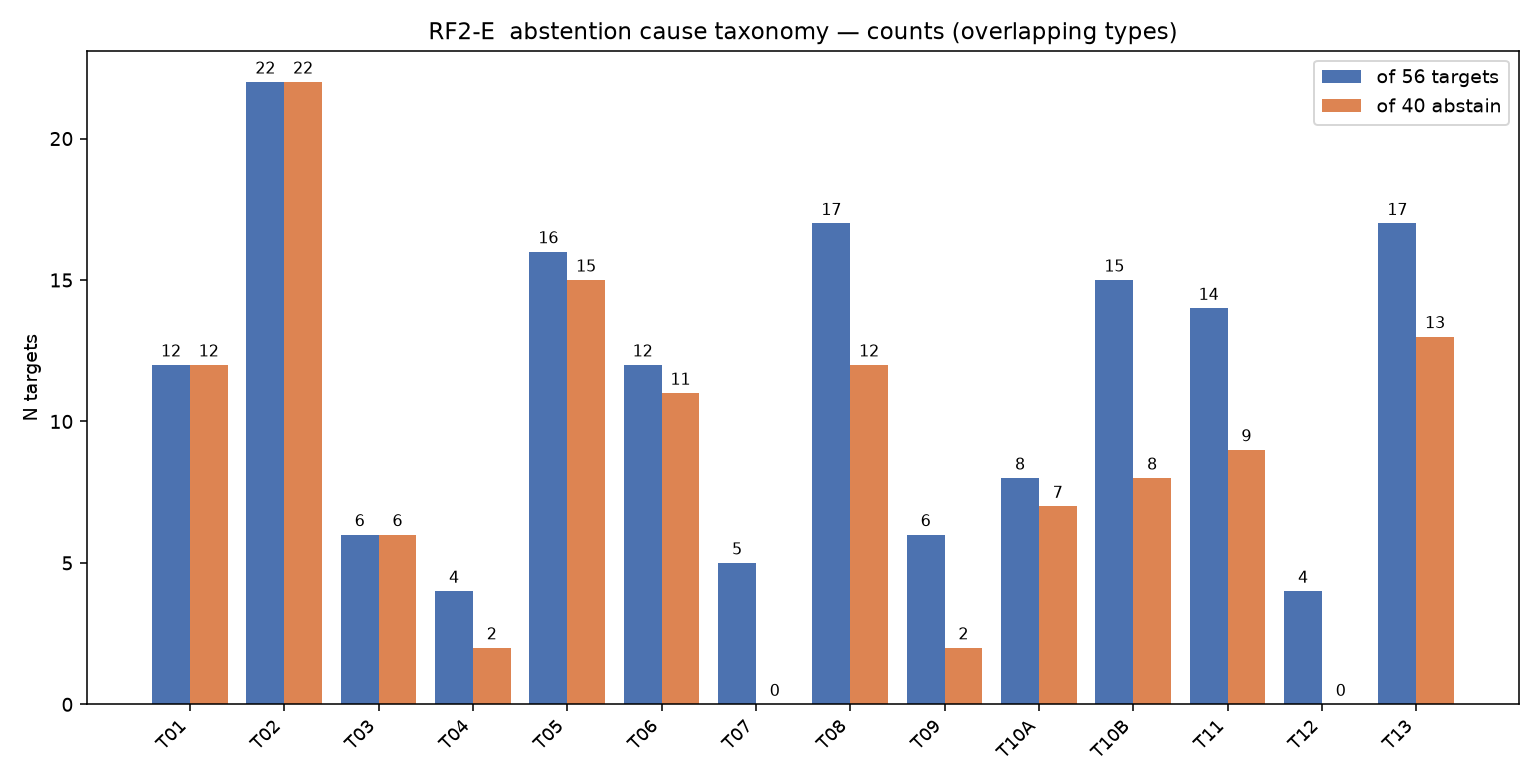

In [5]:
from IPython.display import Image, display
display(Image(str(RD / "figures" / "RF2_E_taxonomy_counts.png")))

## 3. 유형 정의 전문

In [6]:
for t, v in TT.items():
    print(f"### {t} — {v['name']}  [{v['family']}]")
    print(v["definition"])
    if v.get("subtypes"):
        print("  하위구분:", json.dumps(v["subtypes"], ensure_ascii=False))
    print(f"  N: 56/{v['n_of_56']}  abstain40/{v['n_of_abstain40']}  "
          f"unresolved45/{v['n_of_unresolved45']}  mapped11/{v['n_of_mapped11']}")
    print(f"  해결가능성: {v['resolvability']}\n     {v['resolvability_grounds']}\n")

### T01_NO_PREDICATE_FIRED — 어떤 술어도 발화하지 않음 (insufficient evidence)  [EVIDENCE_SHAPE]
Stage3 가 실제로 평가되었고(= 14개 R/E 술어가 trace 에 기록됨), 그 14개 중 단 하나도 fired=true 가 아니다. 관측된 표면에 SSOT §5 가 정의한 어떤 archetype 의 region 신호도 endpoint 신호도 없다는 뜻이다. 이것은 **원인이 아니라 증상**이며, 아래 표면유형/수집품질 유형으로 분해되어야 한다.
  N: 56/12  abstain40/12  unresolved45/12  mapped11/0
  해결가능성: DECOMPOSES
     증상이지 원인이 아니다. 아래 표면/수집 유형으로 분해한 뒤 판단한다.

### T02_WEAK_ONE_SIDED_EVIDENCE — 한쪽 신호만 있는 약한 후보 (region 만 또는 endpoint 만)  [EVIDENCE_SHAPE]
Stage3 술어가 1개 이상 발화했으나 R 과 E 를 동시에 만족하는 branch 가 하나도 없다(strong=∅, weak≠∅). SSOT §6 의 '유일 후보' 조건을 만족할 수 없어 확정 불가다.
  하위구분: {"ENDPOINT_ONLY__REGION_MISSING": 11, "BOTH_SIDES_BUT_DIFFERENT_BRANCHES": 5, "REGION_ONLY__ENDPOINT_MISSING": 6}
  N: 56/22  abstain40/22  unresolved45/22  mapped11/0
  해결가능성: COLLECTION_OR_DEFINITION
     R 또는 E 중 한쪽만 붙었다. 누락된 쪽이 endpoint 인 경우는 상호작용 1스텝 수집으로 확인 가능하고, 누락된 쪽이 region 인 경우는 §5 region 정의의 조작화 문제다.

### T03_MULTI_STRONG_CANDIDATE — 강한 후보가 둘 이상  [EVIDENCE_SHAPE]
R 과

## 4. evidence example — 유형별 근거 관측값

In [7]:
ex = pd.DataFrame([{"type": t.split("_", 1)[0], "wtg": e["wtg"][:12], "service": e["service"],
                    "prior": e["prior_archetype"],
                    "leaf": e["leaf"].replace("AMBIGUOUS_UNRESOLVED__", "AU__"),
                    "final_url": e["final_url"][:52], "why": e["why"][:70]}
                   for t, v in TT.items() for e in v["evidence_examples"]])
ex

,type,wtg,service,prior,leaf,final_url,why
0,T01,054d78ed187c,쿠팡이츠,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,https://www.coupangeats.com/,Stage3 14개 술어 발화 0 (n_fired=0)
1,T01,0f3bdb2bd0bb,탑마트,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,https://www.seowon.com/,Stage3 14개 술어 발화 0 (n_fired=0)
2,T01,190b4501e441,V3 Mobile Plus,UTILITY_ENTRY,AU__NO_STRONG_CANDIDATE,https://mplweb.ahnlab.com/mplweb/v3mp/main_android.d,Stage3 14개 술어 발화 0 (n_fired=0)
3,T01,35319a420294,토스,FINANCIAL_ACTION_ENTRY,AU__NO_STRONG_CANDIDATE,https://toss.im/,Stage3 14개 술어 발화 0 (n_fired=0)
4,T01,51484a735cdb,컴포즈커피,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,https://composecoffee.com/,Stage3 14개 술어 발화 0 (n_fired=0)
...,...,...,...,...,...,...,...
63,T13,12e3942c0495,GS25,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,https://www.gsretail.com/brand/gs25,"prior=ITEM_DETAIL branch 침묵, 타 branch 발화 n=2"
64,T13,13ed070478ef,Netflix,CONTENT_OPEN,AU__NO_STRONG_CANDIDATE,https://www.netflix.com/kr/login?serverState=Bgi8vuv,"prior=CONTENT_OPEN branch 침묵, 타 branch 발화 n=3"
65,T13,22ffba7a86ea,코스트코,ITEM_DETAIL,QUERY,https://www.costco.co.kr/,"prior=ITEM_DETAIL branch 침묵, 타 branch 발화 n=5"
66,T13,24e6654bfd1a,YouTube,CONTENT_OPEN,AU__NO_STRONG_CANDIDATE,https://m.youtube.com/,"prior=CONTENT_OPEN branch 침묵, 타 branch 발화 n=1"


## 5. 중복 행렬 — 한 target 이 여러 유형에 해당한다

In [8]:
T = O["overlap"]["types"]
short = [t.split("_", 1)[0] for t in T]
M = pd.DataFrame(O["overlap"]["matrix_of_abstain40"], index=short, columns=short)
print("target 당 유형 수:", O["overlap"]["n_types_per_target"])
print("유형이 하나도 없는 target:", O["overlap"]["targets_with_zero_type"])
M

target 당 유형 수: {'mean': 2.8214285714285716, 'median': 3.0, 'max': 5, 'distribution': {'3': 23, '4': 11, '2': 12, '1': 6, '5': 3, '0': 1}}
유형이 하나도 없는 target: ['efda6e0b8457d63c']


,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10A,T10B,T11,T12,T13
T01,12,0,0,0,7,3,0,4,1,6,0,1,0,0
T02,0,22,0,1,8,7,0,5,1,1,5,6,0,13
T03,0,0,6,1,0,1,0,3,0,0,3,2,0,0
T04,0,1,1,2,1,0,0,0,0,0,1,0,0,0
T05,7,8,0,1,15,4,0,4,0,3,2,2,0,2
T06,3,7,1,0,4,11,0,5,0,0,2,2,0,6
T07,0,0,0,0,0,0,0,0,0,0,0,0,0,0
T08,4,5,3,0,4,5,0,12,0,3,3,3,0,5
T09,1,1,0,0,0,0,0,0,2,0,0,0,0,0
T10A,6,1,0,0,3,0,0,3,0,7,0,1,0,1


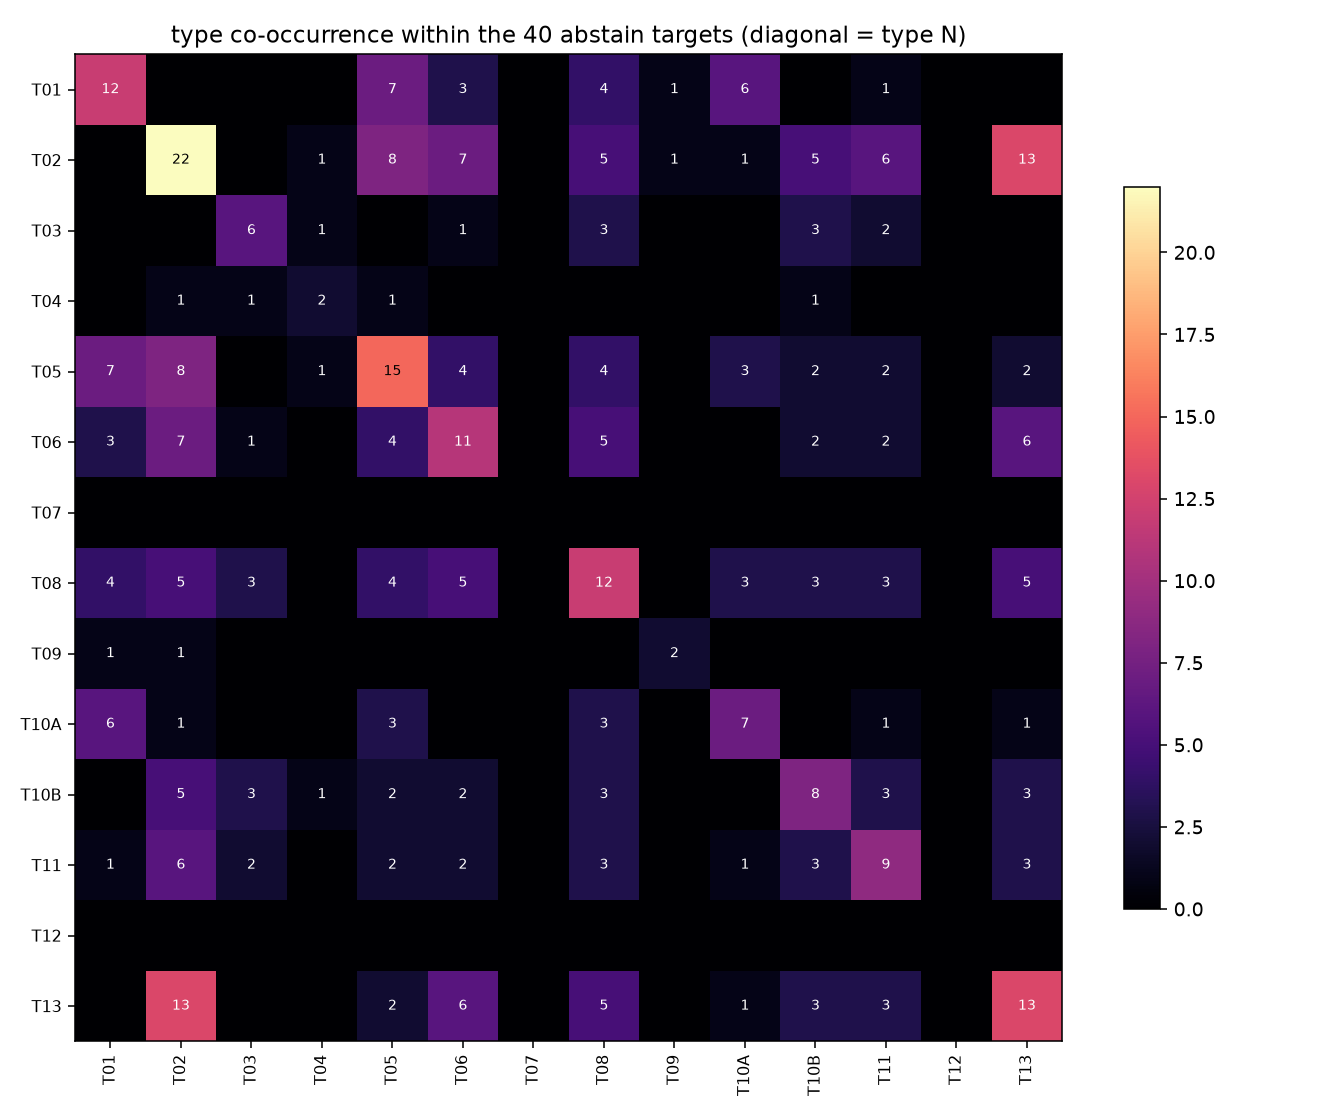

In [9]:
display(Image(str(RD / "figures" / "RF2_E_overlap_matrix.png")))

## 6. T01(무발화)은 원인이 아니라 증상이다

In [10]:
td = O["T01_decomposition"]
print(f"T01 n={td['n']}  다른 유형으로 설명됨={td['explained_by_at_least_one_surface_or_capture_type']}"
      f"  미설명={td['unexplained']}")
pd.Series({k: v for k, v in td["breakdown"].items() if v}).sort_values(ascending=False).to_frame("겹치는 T01 건수")

T01 n=12  다른 유형으로 설명됨=11  미설명=['51484a735cdb487b']


,겹치는 T01 건수
T05_GENERIC_BRAND_LANDING,7
T10A_TEXT_ENCODING_CORRUPTION,6
T08_LOGIN_DOMINATED,4
T06_APP_INSTALL_SURFACE,3
T09_CLIENT_RENDER_SPARSE,1
T11_OVERLAY_OBSTRUCTED,1


## 7. 해결 가능 vs 원리적 미결정

한 target 이 여러 유형에 해당하므로, 해결가능성 집계에는 고정 우선순위 (표면부재 > 퇴화캡처 > 렌더희소 > 인코딩 > 브랜드면 > 앱면 > 오버레이 > 절단 > 로그인 > 공유신호 > 다중강후보 > 약한증거 > prior충돌 > 무발화) 로 primary type 을 하나 정한다. 우선순위는 '수집으로 고칠 수 있는 것' 보다 '표면이 애초에 없는 것' 을 앞에 둔다 — 뒤집으면 미결정이 과소계상된다. 

primary-type 배정:
  of_56              {'UNDECIDABLE_AT_THIS_URL': 27, 'RESOLVABLE': 27, 'OTHER': 2}
  of_abstain40       {'UNDECIDABLE_AT_THIS_URL': 19, 'RESOLVABLE': 20, 'OTHER': 1}
  of_unresolved45    {'UNDECIDABLE_AT_THIS_URL': 24, 'RESOLVABLE': 20, 'OTHER': 1}

우선순위-무관 하한/상한 (abstain 40):
  any_surface_absent_type_of_abstain40          22
  any_capture_quality_type_of_abstain40         22
  both_of_abstain40                             10
  neither_of_abstain40                          6
  any_surface_absent_type_of_56                 28
  any_capture_quality_type_of_56                34

민감도(우선순위 역전): {'OTHER': 12, 'RESOLVABLE': 15, 'UNDECIDABLE_AT_THIS_URL': 13}


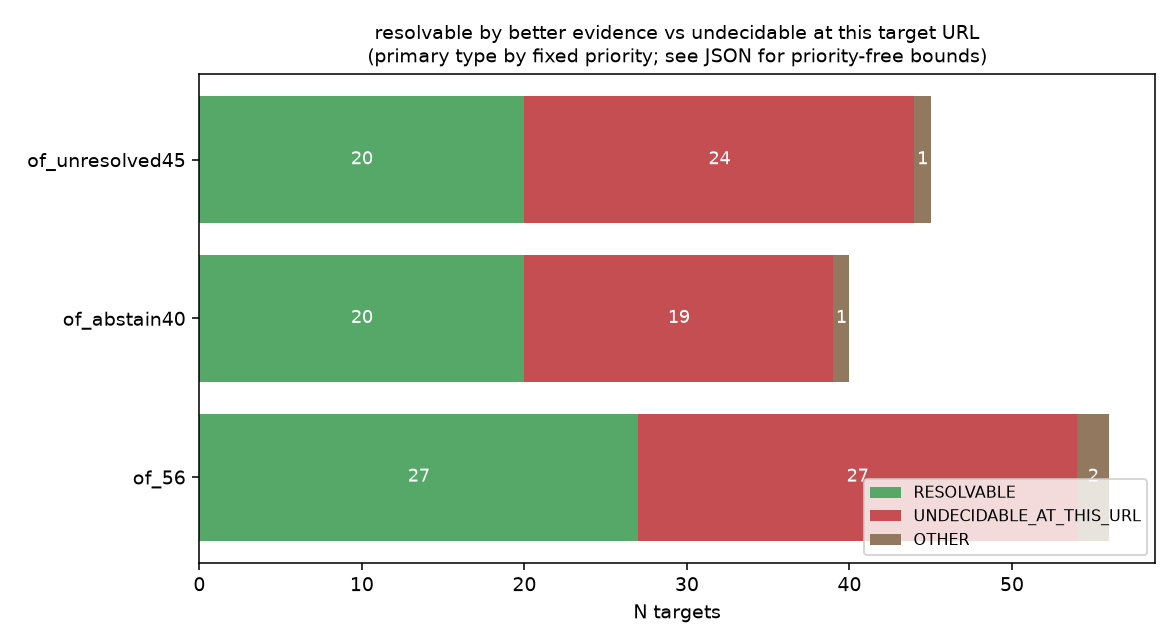

In [11]:
RS = O["resolvability"]
print(RS["assignment_rule"], "\n")
print("primary-type 배정:")
for c in ("of_56", "of_abstain40", "of_unresolved45"):
    print(f"  {c:<18} {RS[c]}")
print("\n우선순위-무관 하한/상한 (abstain 40):")
for k, v in RS["priority_free_bounds"].items():
    if isinstance(v, int):
        print(f"  {k:<45} {v}")
print("\n민감도(우선순위 역전):", RS["sensitivity_reversed_priority"]["of_abstain40"])
display(Image(str(RD / "figures" / "RF2_E_resolvability.png")))

## 8. coverage ↔ confidence

**threshold 를 선언하지 않는다.** SSOT v2.1 §7 은 운영 threshold 를 independent label
calibration split 에서 정하라고 하고, D 는 그 label 을 열지 않았다. 아래는 곡선과
'어디서 기울기가 꺾이는가' 의 관찰뿐이다.

In [12]:
CC = O["coverage_confidence_curves"]
print(CC["note"])
print("prior 다수 class 기저율:", round(CC["base_rate_prior_majority"], 3), "\n")
for key in ("rule_confidence", "semantic_margin", "cascade_rule_then_semantic",
            "cascade_gated_by_surface_absent"):
    d = CC[key]["steepest_agreement_gain_per_coverage_loss"]
    print(f"{key:<36} coverage {d['coverage_low']:.2f}->{d['coverage_high']:.2f}  "
          f"agreement {d['agreement_at_low_coverage']:.3f}->{d['agreement_at_high_coverage']:.3f}")

threshold 를 선언하지 않는다. SSOT §7 은 운영 threshold 를 independent label calibration split 에서 정하라고 하고, D 는 그 label 을 열지 않았다. 여기 있는 것은 곡선과 기울기 변화점뿐이다.
prior 다수 class 기저율: 0.464 

rule_confidence                      coverage 0.70->1.00  agreement 0.410->0.286
semantic_margin                      coverage 0.57->0.61  agreement 0.906->0.853
cascade_rule_then_semantic           coverage 0.27->0.29  agreement 0.667->0.625
cascade_gated_by_surface_absent      coverage 0.30->0.32  agreement 0.647->0.611


In [13]:
def curve_df(key, xk="threshold"):
    c = CC[key]["curve"]
    xk = xk if xk in c[0] else "margin_threshold"
    return pd.DataFrame([{"threshold": r[xk], "n": r["coverage_n"], "coverage": round(r["coverage"], 3),
                          "prior_agreement": round(r["prior_agreement"], 3),
                          "wilson95": [round(x, 2) for x in r["wilson95"]]} for r in c])

print("=== 축 1 rule confidence ==="); display(curve_df("rule_confidence"))
print("구간별 band:"); display(pd.DataFrame(CC["rule_confidence"]["bands"]))

=== 축 1 rule confidence ===


,threshold,n,coverage,prior_agreement,wilson95
0,0.0,56,1.000,0.286,"[0.18, 0.41]"
1,1.0,39,0.696,0.410,"[0.27, 0.57]"
2,1.5,27,0.482,0.481,"[0.31, 0.66]"
3,2.0,17,0.304,0.529,"[0.31, 0.74]"
4,2.5,11,0.196,0.545,"[0.28, 0.79]"
5,3.0,3,0.054,0.333,"[0.06, 0.79]"


구간별 band:


,band,n,agree_k,prior_agreement,wilson95
0,"[0,0.5)",17,0,0.000000,"[0.0, 0.18432366037156456]"
1,"[0.5,1)",0,0,NaN,"[nan, nan]"
2,"[1,1.5)",12,3,0.250000,"[0.08894003962896137, 0.53231033912066]"
3,"[1.5,2)",10,4,0.400000,"[0.16817758120350967, 0.6873304525498135]"
4,"[2,3)",14,8,0.571429,"[0.3259026690286935, 0.7861949006959947]"
5,"[3,3.001)",3,1,0.333333,"[0.061490315276160515, 0.7923450448735121]"


=== 축 2 semantic margin (bge-m3 x SSOT §7 prototype, D 가 독립 재계산) ===


,threshold,n,coverage,prior_agreement,wilson95
0,0.000153,56,1.000,0.679,"[0.55, 0.79]"
2,0.000979,52,0.929,0.712,"[0.58, 0.82]"
4,0.002270,48,0.857,0.729,"[0.59, 0.83]"
6,0.006367,44,0.786,0.773,"[0.63, 0.87]"
8,0.009322,40,0.714,0.800,"[0.65, 0.9]"
10,0.013026,36,0.643,0.861,"[0.71, 0.94]"
12,0.017777,32,0.571,0.906,"[0.76, 0.97]"
14,0.021426,28,0.500,0.893,"[0.73, 0.96]"
16,0.031401,24,0.429,0.917,"[0.74, 0.98]"
18,0.035103,20,0.357,0.900,"[0.7, 0.97]"


margin 5분위 band — 2분위와 3분위 사이에서 꺾인다:


,band,n,agree_k,prior_agreement,wilson95
0,"[0.0001533,0.005606)",11,4,0.363636,"[0.15166223614131386, 0.6462032231083628]"
1,"[0.005606,0.01668)",11,5,0.454545,"[0.21270957543988048, 0.7199122443100118]"
2,"[0.01668,0.03273)",11,8,0.727273,"[0.4343497069897538, 0.9025411942607853]"
3,"[0.03273,0.04752)",11,10,0.909091,"[0.6226353745137962, 0.9837682477371741]"
4,"[0.04752,0.09169)",12,11,0.916667,"[0.6461140782014047, 0.9851352905492264]"


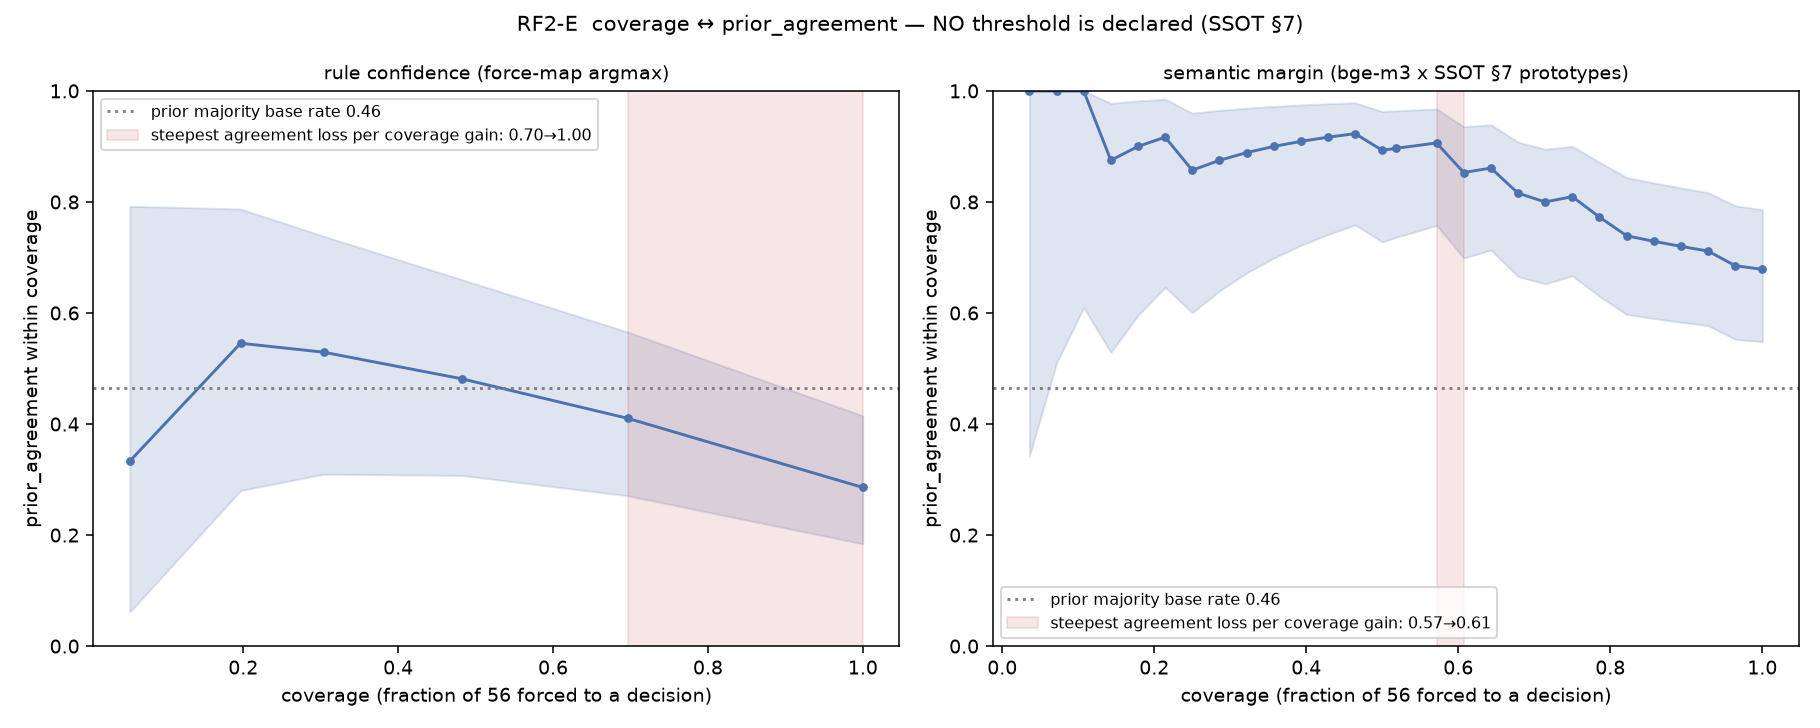

In [14]:
print("=== 축 2 semantic margin (bge-m3 x SSOT §7 prototype, D 가 독립 재계산) ===")
display(curve_df("semantic_margin").iloc[::2])
print("margin 5분위 band — 2분위와 3분위 사이에서 꺾인다:")
display(pd.DataFrame(CC["semantic_margin"]["bands"]))
display(Image(str(RD / "figures" / "RF2_E_coverage_confidence.png")))

In [15]:
print("=== brand leak 대조군 ===")
print(CC["semantic_margin_debranded"]["brand_leak_warning"], "\n")
a, b = CC["semantic_margin"]["curve"], CC["semantic_margin_debranded"]["curve"]
at = lambda c, cov: round(min(c, key=lambda r: abs(r["coverage"] - cov))["prior_agreement"], 3)
pd.DataFrame({"coverage": [1.0, 0.79, 0.57, 0.36],
              "원본 blob": [at(a, x) for x in (1.0, .79, .57, .36)],
              "debranded": [at(b, x) for x in (1.0, .79, .57, .36)]}).set_index("coverage")

=== brand leak 대조군 ===
prior_archetype 은 prior_business_domain 과 1:1 이다(RF001-B). 텍스트에 브랜드/도메인 어휘가 남아 있으면 semantic top1 의 prior_agreement 는 '표면 기능 식별'이 아니라 '브랜드로부터 prior 복원'을 재는 것일 수 있다. 아래 debranded 대조군과 비교해서만 읽어라. 



,원본 blob,debranded
coverage,,
1.00,0.679,0.696
0.79,0.773,0.750
0.57,0.906,0.812
0.36,0.900,0.950


=== 축 3 SSOT §6 -> §7 캐스케이드 ===


,threshold,n,coverage,prior_agreement,wilson95
0,0.000153,56,1.000,0.643,"[0.51, 0.76]"
3,0.001217,51,0.911,0.667,"[0.53, 0.78]"
6,0.006367,45,0.804,0.711,"[0.57, 0.82]"
9,0.009576,40,0.714,0.725,"[0.57, 0.84]"
12,0.017777,35,0.625,0.771,"[0.61, 0.88]"
15,0.023406,30,0.536,0.767,"[0.59, 0.88]"
18,0.035103,24,0.429,0.708,"[0.51, 0.85]"
21,0.044988,20,0.357,0.650,"[0.43, 0.82]"
24,0.056022,16,0.286,0.625,"[0.39, 0.82]"
27,0.078478,12,0.214,0.583,"[0.32, 0.81]"


표면부재 유형(T05/T06/T07)을 먼저 abstain 시킨 대조 — 같은 threshold 에서 agreement 가 낮다:


,threshold,n,coverage,prior_agreement,wilson95
0,0.000153,28,0.500,0.607,"[0.42, 0.76]"
3,0.001217,24,0.429,0.625,"[0.43, 0.79]"
6,0.006367,22,0.393,0.636,"[0.43, 0.8]"
9,0.009576,19,0.339,0.632,"[0.41, 0.81]"
12,0.017777,18,0.321,0.611,"[0.39, 0.8]"
15,0.023406,17,0.304,0.647,"[0.41, 0.83]"
18,0.035103,16,0.286,0.625,"[0.39, 0.82]"
21,0.044988,15,0.268,0.600,"[0.36, 0.8]"
24,0.056022,13,0.232,0.538,"[0.29, 0.77]"
27,0.078478,10,0.179,0.500,"[0.24, 0.76]"


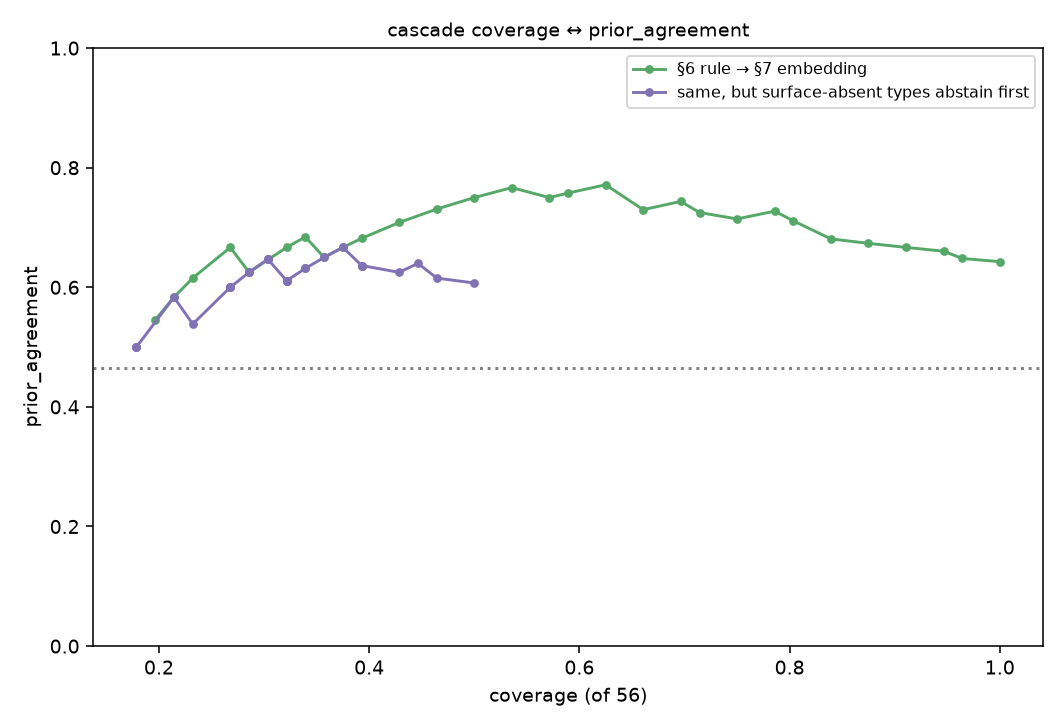

In [16]:
print("=== 축 3 SSOT §6 -> §7 캐스케이드 ===")
display(curve_df("cascade_rule_then_semantic").iloc[::3])
print("표면부재 유형(T05/T06/T07)을 먼저 abstain 시킨 대조 — 같은 threshold 에서 agreement 가 낮다:")
display(curve_df("cascade_gated_by_surface_absent").iloc[::3])
display(Image(str(RD / "figures" / "RF2_E_cascade_curve.png")))

## 9. force-map 비용 — abstention 세탁의 값

In [17]:
F = O["force_map_cost"]
print(F["cost_summary"]["reading"], "\n")
rows = [("rule argmax", "rule_argmax"),
        ("SSOT §6 이 금지한 first match", "ssot6_forbidden_first_match"),
        ("semantic top1", "semantic_top1"),
        ("semantic top1 debranded", "semantic_top1_debranded")]
display(pd.DataFrame([{"방식": lab, **{k: (round(v, 3) if isinstance(v, float) else v)
                                     for k, v in F[k2]["overall_abstain40"].items()
                                     if k != "wilson95_disagreement"}}
                      for lab, k2 in rows]).set_index("방식"))
print("대조 — rule 이 실제로 확정한 11건:", F["rule_argmax"]["on_mapped11_for_contrast"])

SSOT §6 은 유일 후보가 아니면 AMBIGUOUS_UNRESOLVED 로 남기라고 한다. 아래는 그 규정을 무시하고 abstain 40건에 강제로 하나를 고를 때의 prior 불일치 비용이다. prior 는 gold 가 아니므로 '오류율'이 아니라 '불일치율'로만 읽어야 한다. 



,n,agree,disagree,disagreement_rate
방식,,,,
rule argmax,40,10,30,0.750
SSOT §6 이 금지한 first match,40,9,31,0.775
semantic top1,40,25,15,0.375
semantic top1 debranded,40,26,14,0.350


대조 — rule 이 실제로 확정한 11건: {'n': 11, 'agree': 6, 'disagreement_rate': 0.4545454545454546}


,type,name,n(abstain40),rule argmax,first match,semantic top1,debranded
0,T01,어떤 술어도 발화하지 않음 (insufficient evidence),12,1.00,1.00,0.50,0.42
11,T13,business prior 가 관측 구조와 어긋남,13,1.00,1.00,0.38,0.38
8,T10A,텍스트 인코딩 훼손 (mojibake),7,1.00,1.00,0.57,0.57
6,T08,로그인 지배 표면,12,0.92,1.00,0.33,0.42
5,T06,앱 설치/전환 유도 면,11,0.91,0.91,0.55,0.45
1,T02,한쪽 신호만 있는 약한 후보 (region 만 또는 endpoint 만),22,0.68,0.68,0.23,0.23
10,T11,오버레이/모달로 대표 표면이 가려짐,9,0.67,0.78,0.33,0.22
4,T05,일반 기업/브랜드 소개 면,15,0.67,0.67,0.27,0.27
9,T10B,텍스트/후보 절단 (cap),8,0.62,0.62,0.38,0.38
2,T03,강한 후보가 둘 이상,6,0.50,0.67,0.67,0.67


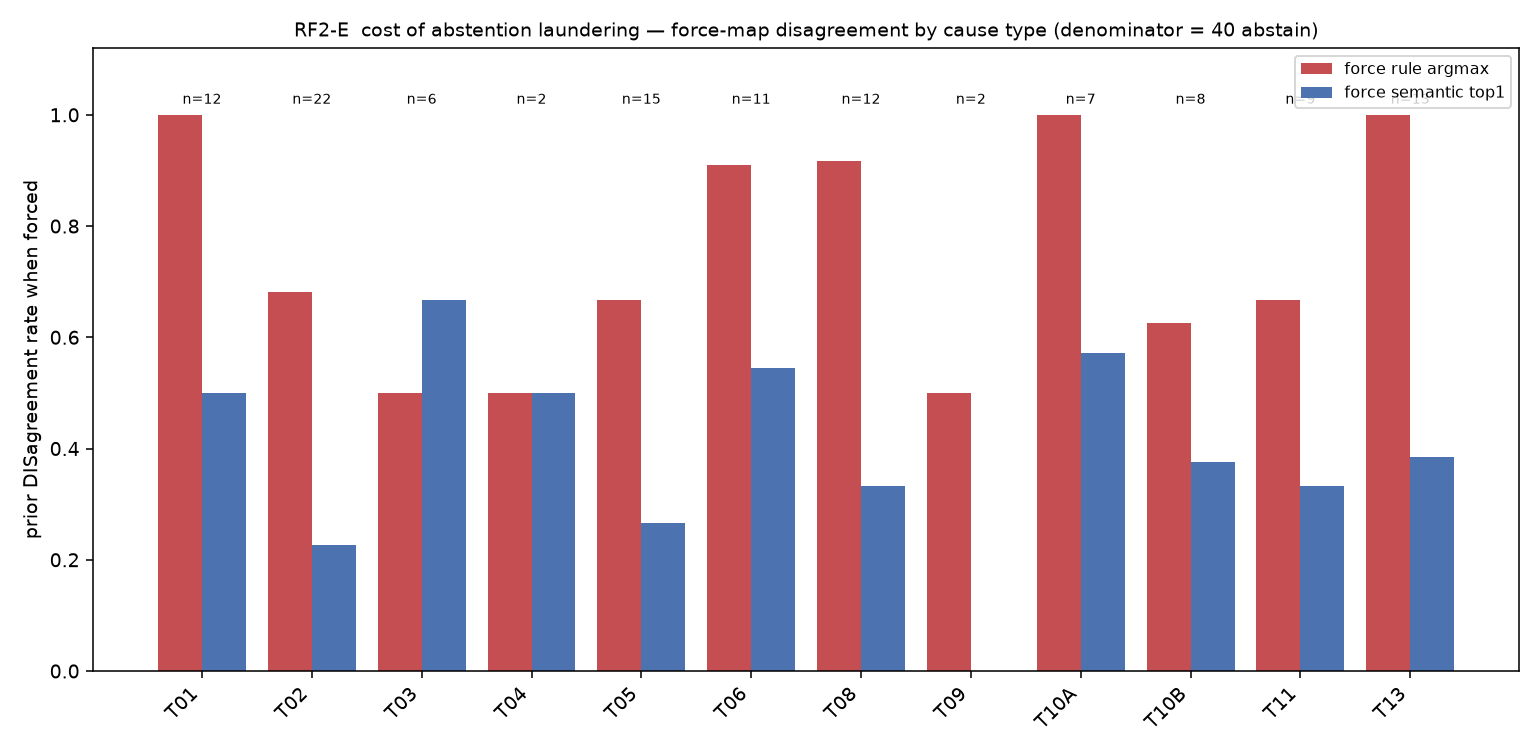

In [18]:
pr, pf = F["rule_argmax"]["per_type"], F["ssot6_forbidden_first_match"]["per_type"]
ps, pd_ = F["semantic_top1"]["per_type"], F["semantic_top1_debranded"]["per_type"]
cost = pd.DataFrame([{"type": t.split("_", 1)[0], "name": TT[t]["name"],
                      "n(abstain40)": pr[t]["n_in_abstain40"],
                      "rule argmax": round(pr[t]["disagreement_rate"], 2),
                      "first match": round(pf[t]["disagreement_rate"], 2),
                      "semantic top1": round(ps[t]["disagreement_rate"], 2),
                      "debranded": round(pd_[t]["disagreement_rate"], 2)}
                     for t in T if pr[t]["n_in_abstain40"]])
display(cost.sort_values("rule argmax", ascending=False))
display(Image(str(RD / "figures" / "RF2_E_forcemap_cost.png")))

## 10. 반례 · per-target 표

In [19]:
for c in O["counterexamples"]:
    print("-", c["kind"])
    print("   ", {k: v for k, v in c.items() if k != "kind"})

- 브랜드/앱면 유형인데 rule 이 확정한 케이스 — '브랜드면=미결정' 주장의 반례
    {'wtg': '95e22b9aff7196b3', 'service': 'NS홈쇼핑', 'leaf': 'ITEM_DETAIL', 'strong': ['ITEM_DETAIL'], 'prior_archetype': 'ITEM_DETAIL'}
- 어떤 표면/수집 유형으로도 설명되지 않는 무발화 — taxonomy 의 미설명 잔여
    {'wtg': '51484a735cdb487b', 'service': '컴포즈커피'}
- 인코딩 훼손인데도 rule 이 확정 — '인코딩 훼손 => 미결정' 의 반례
    {'wtg': 'ea031f85e857140e', 'service': '메가커피', 'leaf': 'QUERY'}


In [20]:
pt = pd.DataFrame(O["per_target"])
pt["types"] = pt["types"].map(lambda xs: ",".join(x.split("_", 1)[0] for x in xs))
pt[["wtg", "service", "prior_archetype", "leaf", "rule_conf", "rule_argmax",
    "sem_top1", "sem_margin", "primary_type", "resolvability_bucket", "types"]] \
    .assign(wtg=lambda d: d.wtg.str[:10],
            leaf=lambda d: d.leaf.str.replace("AMBIGUOUS_UNRESOLVED__", "AU__"),
            sem_margin=lambda d: d.sem_margin.round(4),
            primary_type=lambda d: d.primary_type.str.split("_").str[0])

,wtg,service,prior_archetype,leaf,rule_conf,rule_argmax,sem_top1,sem_margin,primary_type,resolvability_bucket,types
0,054d78ed18,쿠팡이츠,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,0.0,QUERY,COMMUNICATION_ENTRY,0.0012,T05,UNDECIDABLE_AT_THIS_URL,"T01,T05,T06"
1,088809bf9b,삼성카드,FINANCIAL_ACTION_ENTRY,AU__MULTI_CANDIDATE,2.0,QUERY,FINANCIAL_ACTION_ENTRY,0.0333,T11,RESOLVABLE,"T03,T08,T10B,T11"
2,0ee385d0c9,홈플러스,ITEM_DETAIL,ITEM_DETAIL,2.5,ITEM_DETAIL,ITEM_DETAIL,0.0475,T11,RESOLVABLE,"T10B,T11"
3,0f3bdb2bd0,탑마트,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,0.0,QUERY,ITEM_DETAIL,0.0315,T10A,RESOLVABLE,"T01,T05,T10A"
4,12e3942c04,GS25,ITEM_DETAIL,AU__NO_STRONG_CANDIDATE,1.0,CONTENT_OPEN,ITEM_DETAIL,0.0208,T05,UNDECIDABLE_AT_THIS_URL,"T02,T05,T13"
5,13ed070478,Netflix,CONTENT_OPEN,AU__NO_STRONG_CANDIDATE,1.0,PLACE_LOOKUP,CONTENT_OPEN,0.0004,T08,RESOLVABLE,"T02,T08,T13"
6,190b4501e4,V3 Mobile Plus,UTILITY_ENTRY,AU__NO_STRONG_CANDIDATE,0.0,QUERY,FINANCIAL_ACTION_ENTRY,0.0012,T10A,RESOLVABLE,"T01,T10A,T11"
7,22ffba7a86,코스트코,ITEM_DETAIL,QUERY,2.5,QUERY,ITEM_DETAIL,0.0183,T10B,RESOLVABLE,"T08,T10B,T13"
8,24e6654bfd,YouTube,CONTENT_OPEN,AU__NO_STRONG_CANDIDATE,1.5,QUERY,QUERY,0.0068,T10A,RESOLVABLE,"T02,T10A,T13"
9,35319a4202,토스,FINANCIAL_ACTION_ENTRY,AU__NO_STRONG_CANDIDATE,0.0,QUERY,FINANCIAL_ACTION_ENTRY,0.0143,T05,UNDECIDABLE_AT_THIS_URL,"T01,T05,T06"


## 11. LIMITATION

In [21]:
print(O["limitation"])
print("\n가장 무거운 것: 해결가능성 판정은 반사실(counterfactual) 주장이다. "
      "RESOLVABLE 20 / UNDECIDABLE 19 는 재수집 실험의 가설이지 결과가 아니다.")
print("\n" + META["firewall"])
print("\nMLflow run:", META["mlflow_run_id"], "| experiment:", META["mlflow_experiment"])

1) prior_archetype 은 gold 가 아니다. 모든 '불일치'는 rule 오류일 수도 prior 오류일 수도 있고 D 는 label 을 열지 않아 가를 수 없다. 2) 유형 판정에 쓰인 어휘 사전·경로 마커·구성요소 개수 임계는 D 가 정한 조작화이며 SSOT 에 명문화된 것이 아니다. 3) n=56, 유형별 N 이 3~20 이라 유형별 비율의 CI 가 매우 넓다. 4) 해결가능성 판정은 반사실(counterfactual) 주장이므로 재수집 실험 없이는 검증되지 않는다. 5) 곡선은 prior 기준이므로 운영 threshold 결정에 그대로 쓸 수 없다.

가장 무거운 것: 해결가능성 판정은 반사실(counterfactual) 주장이다. RESOLVABLE 20 / UNDECIDABLE 19 는 재수집 실험의 가설이지 결과가 아니다.

holdout label 을 열지 않았다 — LABEL_SPLIT_FROZEN*, HOLDOUT_FOR_C*, RAW_L1~L4*, PACKET_L*, *_OVERLAP*, PRECEDENCE_CONTESTED*, CALIBRATION_FOR_B*, **/control/** 은 이 분석에서 한 번도 읽지 않았다. 그래서 threshold 를 선언하지 않는다.

MLflow run: 17e95f2163374200a3cbfa190b077933 | experiment: LA_03_RF_MAPPING
